# Lab_2: Using simple classification methods for solving classification problem
# Task:
1. Do data preprocessing & data visualization as it was in the 1st lab work
2. Solve classification problem for the selected dataset.
3. Use `examples/fisher_irises.ipynb` as baseline for your experiments
4. Try to optimize hyperparameters of some model

### Chosen Dataset for classification : [Gender Classification Dataset](https://www.kaggle.com/datasets/elakiricoder/gender-classification-dataset)


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('gender_classification_v7.csv')

df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [22]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["gender"] = label_encoder.fit_transform(df["gender"])
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,1
1,0,14.0,5.4,0,0,1,0,0
2,0,11.8,6.3,1,1,1,1,1
3,0,14.4,6.1,0,1,1,1,1
4,1,13.5,5.9,0,0,0,0,0


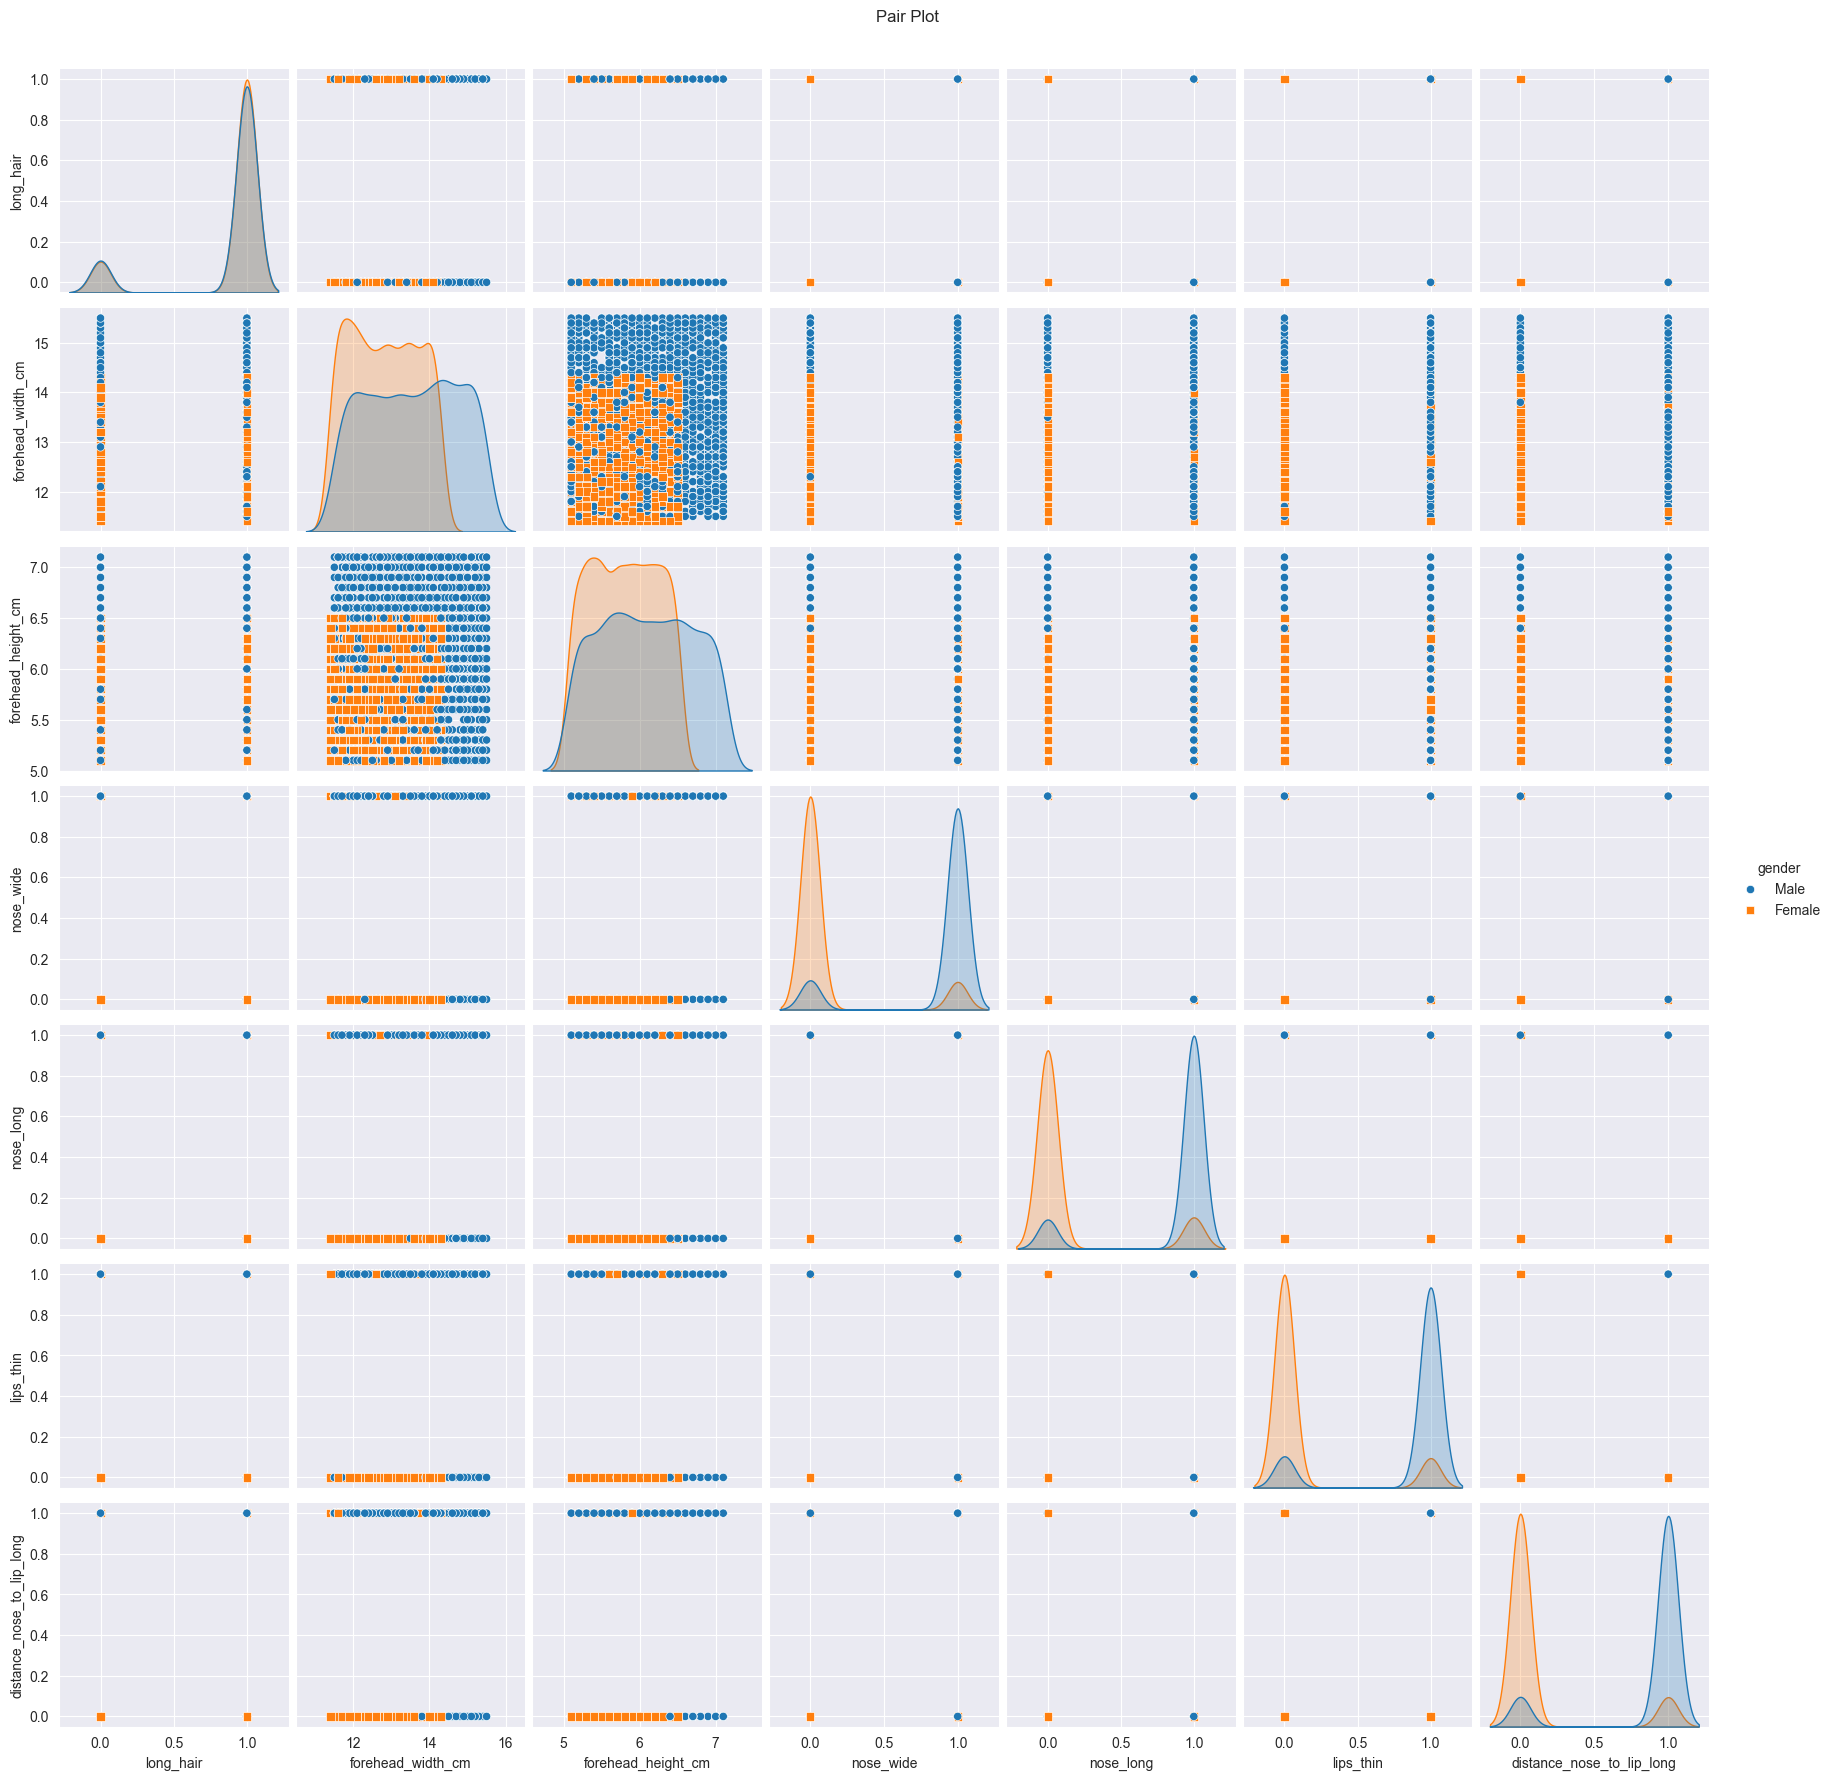

In [12]:
sns.pairplot(df, hue='gender', markers=["o", "s"])
plt.suptitle("Pair Plot", y=1.02)
plt.show()

In [23]:
X = df.drop(columns=["gender"])
y = df["gender"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

y_train.value_counts(normalize=True)

gender
1    0.5
0    0.5
Name: proportion, dtype: float64

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def metrics(test, pred):
    accuracy = accuracy_score(test, pred)
    precision = precision_score(test, pred)
    recall = recall_score(test, pred)
    f1 = f1_score(test, pred)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


In [32]:
from sklearn.metrics import confusion_matrix, roc_curve, auc


def plot_confusion_matrix(test, pred):
    cm = confusion_matrix(test, pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Female", "Male"], yticklabels=["Female", "Male"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


In [40]:
def plot_roc_curve(predicted_probabilities, output_test):
    fpr, tpr, _ = roc_curve(output_test, predicted_probabilities)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

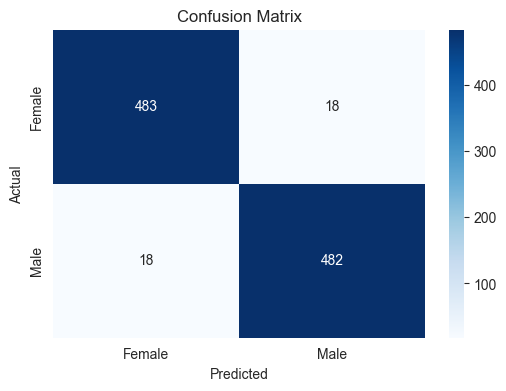

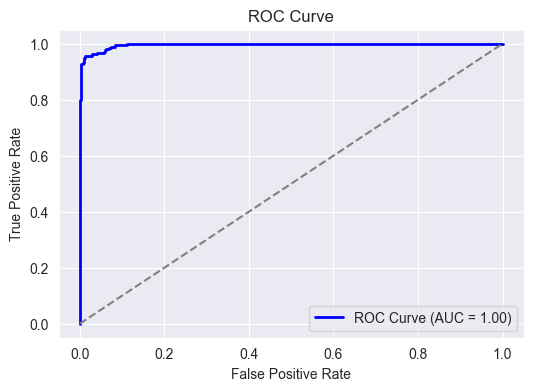

In [48]:
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression()
lg.fit(X_train, y_train)

y_pred = lg.predict(X_test)

metrics(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred)
plot_roc_curve(lg.predict_proba(X_test)[:, 1], y_test)

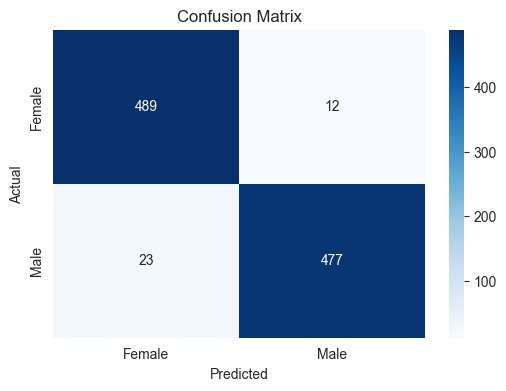

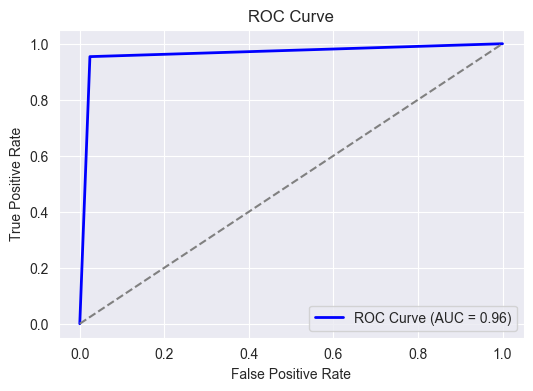

In [49]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

metrics(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred)
plot_roc_curve(dt.predict_proba(X_test)[:, 1], y_test)

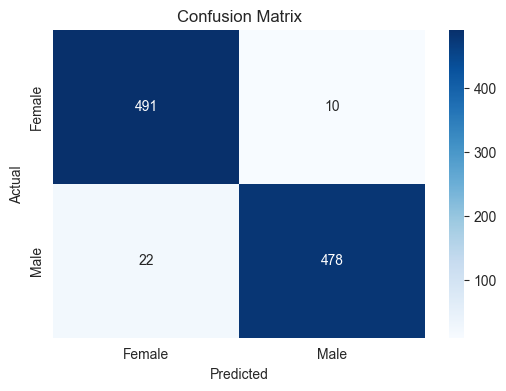

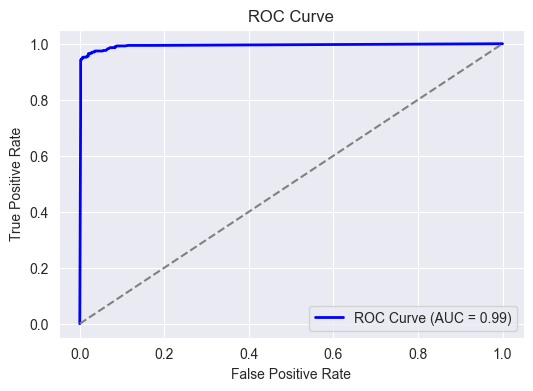

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

metrics(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred)
plot_roc_curve(rf.predict_proba(X_test)[:, 1], y_test)